In [85]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
from shapely.ops import unary_union
import glob
import os

In [86]:
pd.set_option('display.max_rows', 500)

In [87]:
from vista_criticality_utils import *

In [88]:
# Reload modules
import importlib
import vista_criticality_utils 
importlib.reload(vista_criticality_utils)
from vista_criticality_utils import *

# 1. Load assets to a new graph

In [96]:
asset_file = '/home/vagrant/NDTP/VISTA-DEV/vista/data-science/data/03-data-vessel-blocking-port.csv'

In [97]:
incident_data = pd.read_csv(asset_file)

In [98]:
incident_data.head(20)

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id
0,WS01,WaterSupply,WaterReservoir,50.678504,-1.152067,3,WS02
1,SW01,Sewage,WastewaterCollectionNetwork,50.739617,-1.328310,3,SW02
2,SW02,Sewage,WastewaterCollectionNetwork,50.685999,-1.543561,3,SW03
3,SW03,Sewage,WastewaterCollectionNetwork,50.667008,-1.184479,3,NaN
4,SW04,Sewage,WastewaterCollectionNetwork,50.761405,-1.288696,3,NaN
5,PGS01,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.719325,-1.202044,3,PGS02
6,PGS02,PowerGen/Substation,HighVoltageElectricitySubstationComplex,50.710424,-1.253947,3,PGS03
7,PGS03,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.745720,-1.285433,3,NaN
8,PGS04,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.662086,-1.153749,3,NaN
9,WS02,WaterSupply,WaterDistributionComplex,50.618912,-1.186271,3,WS03


In [99]:
incident_data.tail(20)

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id
113,JN15,Named Junction,Lynn Cross,50.703675,-1.243232,3,JN27
114,JN16,Named Junction,Branstone Cross,50.648063,-1.210686,3,JN28
115,JN17,Named Junction,Upton Cross,50.710362,-1.178703,3,JN29
116,JN18,Named Junction,Two Firs,50.659115,-1.211956,3,NaN
117,JN19,Named Junction,Thornton Cross,50.722964,-1.137455,3,NaN
118,JN20,Named Junction,Fighting Cocks Cross,50.653276,-1.220958,3,NaN
119,JN21,Named Junction,Steyne Cross,50.682819,-1.089947,3,NaN
120,JN22,Named Junction,Bartons Corner,50.720819,-1.193537,3,JN05
121,JN23,Named Junction,Westridge Cross,50.715133,-1.146226,3,JN06
122,JN24,Named Junction,Blackwater Junction,50.676125,-1.283394,3,JN07


In [100]:
incident_data.shape

(133, 7)

In [101]:
incident_data.Asset_ID.nunique()

133

In [102]:
#incident_data.Asset_ID.duplicated()

In [103]:
G = load_assets_to_graph(assets_filepath=asset_file)

Successfully loaded /home/vagrant/NDTP/VISTA-DEV/vista/data-science/data/03-data-vessel-blocking-port.csv
Added 133 nodes to the graph.


In [104]:
dependency_file = '/home/vagrant/NDTP/VISTA-DEV/vista/data-science/data/03-ferry-dependency.csv'
asset_dependencies = pd.read_csv(dependency_file)

In [105]:
asset_dependencies.head(10)

,from_asset,to_asset,connection,dependency_score
0,PGS06,TRF02,PGS06-->TRF02,3
1,PGS03,TRF01,PGS03-->TRF01,3
2,TRF02,PH04,TRF02-->PH04,3
3,TRF02,JN27,TRF02-->JN27,3
4,JN27,JN01,JN27-->JN01,3
5,TRF01,JN05,TRF01-->JN05,2
6,JN05,JN11,JN05-->JN11,3
7,TRF02,JN08,TRF02-->JN08,3
8,TRF02,HS01,TRF02-->HS01,3
9,TRF01,HS01,TRF01-->HS01,2


In [106]:
G.nodes['TRF02']

{'Asset_ID': 'TRF02',
 'Asset_Type': 'Transport-Ferry',
 'Asset_Name': 'FerryPort',
 'lat': 50.763106,
 'long': -1.2960338,
 'criticality_score': 3,
 'backup_asset_id': 'TRF01',
 'status': 'working'}

In [107]:
G = add_dependencies_to_graph(graph=G, dependencies_filepath=dependency_file)


Successfully loaded /home/vagrant/NDTP/VISTA-DEV/vista/data-science/data/03-ferry-dependency.csv
Added edges. The graph now has 47 edges.


In [108]:
G.number_of_edges()

47

In [109]:
## Add dependency score aS node attributes
G = compute_dependency_score(G=G)

In [110]:
G.nodes['TRF02']

{'Asset_ID': 'TRF02',
 'Asset_Type': 'Transport-Ferry',
 'Asset_Name': 'FerryPort',
 'lat': 50.763106,
 'long': -1.2960338,
 'criticality_score': 3,
 'backup_asset_id': 'TRF01',
 'status': 'working',
 'dependency_score': 3}

In [111]:
check_node_and_edges(G, node_id='TRF02')


--- Analysis for Node: TRF02 ---

[Asset Attributes]
  - Asset_ID: TRF02
  - Asset_Type: Transport-Ferry
  - Asset_Name: FerryPort
  - lat: 50.763106
  - long: -1.2960338
  - criticality_score: 3
  - backup_asset_id: TRF01
  - status: working
  - dependency_score: 3

[Outgoing Dependencies (This asset depends on...)]
  -> TRF02 impacts PH04 with dependency_score (weight): 3.0
  -> TRF02 impacts JN27 with dependency_score (weight): 3.0
  -> TRF02 impacts JN08 with dependency_score (weight): 3.0
  -> TRF02 impacts HS01 with dependency_score (weight): 3.0
  -> TRF02 impacts PH02 with dependency_score (weight): 3.0

[Incoming Dependencies (...depend on this asset)]
  <- PGS06 is parent to TRF02 with dependency_score (weight): 3.0
------------------------------


In [112]:
incident_data = graph_to_dataframe(G)

In [113]:
incident_data.head(20)

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score
0,WS01,WaterSupply,WaterReservoir,50.678504,-1.152067,3,WS02,working,0
1,SW01,Sewage,WastewaterCollectionNetwork,50.739617,-1.328310,3,SW02,working,0
2,SW02,Sewage,WastewaterCollectionNetwork,50.685999,-1.543561,3,SW03,working,0
3,SW03,Sewage,WastewaterCollectionNetwork,50.667008,-1.184479,3,NaN,working,0
4,SW04,Sewage,WastewaterCollectionNetwork,50.761405,-1.288696,3,NaN,working,0
5,PGS01,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.719325,-1.202044,3,PGS02,working,3
6,PGS02,PowerGen/Substation,HighVoltageElectricitySubstationComplex,50.710424,-1.253947,3,PGS03,working,0
7,PGS03,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.745720,-1.285433,3,NaN,working,3
8,PGS04,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.662086,-1.153749,3,NaN,working,0
9,WS02,WaterSupply,WaterDistributionComplex,50.618912,-1.186271,3,WS03,working,0


## New Exposure Score

In [114]:
flood_layers = '/home/vagrant/NDTP/VISTA-DEV/vista/data-science/data/New_exposure_score_data/flood_files'
heat_stress_layers = '/home/vagrant/NDTP/VISTA-DEV/vista/data-science/data/New_exposure_score_data/heat_stress_files'
landslide_layers = '/home/vagrant/NDTP/VISTA-DEV/vista/data-science/data/New_exposure_score_data/landslide_files'

In [115]:
# Construct the search pattern to find all .geojson files in the specified folder
flood_geojson_search_pattern = os.path.join(flood_layers, '*.geojson')
flood_geojson_file_paths = glob.glob(flood_geojson_search_pattern)

heat_geojson_search_pattern = os.path.join(heat_stress_layers, '*.geojson')
heat_geojson_file_paths = glob.glob(heat_geojson_search_pattern)

landslide_geojson_search_pattern = os.path.join(landslide_layers, '*.geojson')
landslide_geojson_file_paths = glob.glob(landslide_geojson_search_pattern)

In [116]:
incident_data = compute_exposure_score_v2(assets_df=incident_data, flood_files=flood_geojson_file_paths)

In [117]:
incident_data.head(20)

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score,exposure_score
0,WS01,WaterSupply,WaterReservoir,50.678504,-1.152067,3,WS02,working,0,2
1,SW01,Sewage,WastewaterCollectionNetwork,50.739617,-1.328310,3,SW02,working,0,0
2,SW02,Sewage,WastewaterCollectionNetwork,50.685999,-1.543561,3,SW03,working,0,0
3,SW03,Sewage,WastewaterCollectionNetwork,50.667008,-1.184479,3,NaN,working,0,2
4,SW04,Sewage,WastewaterCollectionNetwork,50.761405,-1.288696,3,NaN,working,0,0
5,PGS01,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.719325,-1.202044,3,PGS02,working,3,1
6,PGS02,PowerGen/Substation,HighVoltageElectricitySubstationComplex,50.710424,-1.253947,3,PGS03,working,0,0
7,PGS03,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.745720,-1.285433,3,NaN,working,3,0
8,PGS04,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.662086,-1.153749,3,NaN,working,0,2
9,WS02,WaterSupply,WaterDistributionComplex,50.618912,-1.186271,3,WS03,working,0,1


In [90]:
incident_data.to_csv('exposure_score_with_flood_layer.csv', index=False)

In [118]:
G = add_attribute_from_df(G=G, df=incident_data, column_name='exposure_score')

Added exposure_score to the graph.


In [119]:
G.nodes['WS04']

{'Asset_ID': 'WS04',
 'Asset_Type': 'WaterSupply',
 'Asset_Name': 'WaterExtractionComplex',
 'lat': 50.65748868,
 'long': -1.307015479,
 'criticality_score': 3,
 'backup_asset_id': nan,
 'status': 'working',
 'dependency_score': 0,
 'exposure_score': 2}

In [120]:
incident_data_with_heat_stress_layer = compute_exposure_score_v2(assets_df=incident_data, flood_files=flood_geojson_file_paths, heat_files=heat_geojson_file_paths)

In [121]:
G_flood_heat_layer = add_attribute_from_df(G=G, df=incident_data_with_heat_stress_layer, column_name='exposure_score')

Added exposure_score to the graph.


In [122]:
G_flood_heat_layer.nodes['WS04']

{'Asset_ID': 'WS04',
 'Asset_Type': 'WaterSupply',
 'Asset_Name': 'WaterExtractionComplex',
 'lat': 50.65748868,
 'long': -1.307015479,
 'criticality_score': 3,
 'backup_asset_id': nan,
 'status': 'working',
 'dependency_score': 0,
 'exposure_score': 3}

In [123]:
incident_data_with_heat_stress_layer.head(20)

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score,exposure_score
0,WS01,WaterSupply,WaterReservoir,50.678504,-1.152067,3,WS02,working,0,3
1,SW01,Sewage,WastewaterCollectionNetwork,50.739617,-1.328310,3,SW02,working,0,0
2,SW02,Sewage,WastewaterCollectionNetwork,50.685999,-1.543561,3,SW03,working,0,0
3,SW03,Sewage,WastewaterCollectionNetwork,50.667008,-1.184479,3,NaN,working,0,2
4,SW04,Sewage,WastewaterCollectionNetwork,50.761405,-1.288696,3,NaN,working,0,0
5,PGS01,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.719325,-1.202044,3,PGS02,working,3,1
6,PGS02,PowerGen/Substation,HighVoltageElectricitySubstationComplex,50.710424,-1.253947,3,PGS03,working,0,0
7,PGS03,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.745720,-1.285433,3,NaN,working,3,0
8,PGS04,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.662086,-1.153749,3,NaN,working,0,3
9,WS02,WaterSupply,WaterDistributionComplex,50.618912,-1.186271,3,WS03,working,0,1


In [124]:
#incident_data_with_heat_stress_layer.to_csv('exposure_score_with_flood_heat_layer.csv', index=False)

In [125]:
incident_data_with_heat_stress_landslide_layer= compute_exposure_score_v2(assets_df=incident_data, flood_files=flood_geojson_file_paths, heat_files=heat_geojson_file_paths, landslide_files=landslide_geojson_file_paths)

In [126]:
G_flood_heat_landslide_layer = add_attribute_from_df(G=G, df=incident_data_with_heat_stress_landslide_layer, column_name='exposure_score')

Added exposure_score to the graph.


In [127]:
G_flood_heat_landslide_layer.nodes['WS04']

{'Asset_ID': 'WS04',
 'Asset_Type': 'WaterSupply',
 'Asset_Name': 'WaterExtractionComplex',
 'lat': 50.65748868,
 'long': -1.307015479,
 'criticality_score': 3,
 'backup_asset_id': nan,
 'status': 'working',
 'dependency_score': 0,
 'exposure_score': 3}

In [128]:
incident_data_with_heat_stress_landslide_layer.head(20)

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score,exposure_score
0,WS01,WaterSupply,WaterReservoir,50.678504,-1.152067,3,WS02,working,0,3
1,SW01,Sewage,WastewaterCollectionNetwork,50.739617,-1.328310,3,SW02,working,0,0
2,SW02,Sewage,WastewaterCollectionNetwork,50.685999,-1.543561,3,SW03,working,0,0
3,SW03,Sewage,WastewaterCollectionNetwork,50.667008,-1.184479,3,NaN,working,0,2
4,SW04,Sewage,WastewaterCollectionNetwork,50.761405,-1.288696,3,NaN,working,0,0
5,PGS01,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.719325,-1.202044,3,PGS02,working,3,1
6,PGS02,PowerGen/Substation,HighVoltageElectricitySubstationComplex,50.710424,-1.253947,3,PGS03,working,0,0
7,PGS03,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.745720,-1.285433,3,NaN,working,3,0
8,PGS04,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.662086,-1.153749,3,NaN,working,0,3
9,WS02,WaterSupply,WaterDistributionComplex,50.618912,-1.186271,3,WS03,working,0,1


In [129]:
# incident_data_with_heat_stress_landslide_layer.to_csv('exposure_score_with_flood_heat_landslide_layer.csv',index=False)

## Redundancy Score

In [130]:
incident_data = compute_redundancy_score(df=incident_data)

In [131]:
incident_data.head(20)

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score,exposure_score,redundancy_score
0,WS01,WaterSupply,WaterReservoir,50.678504,-1.152067,3,WS02,working,0,3,2
1,SW01,Sewage,WastewaterCollectionNetwork,50.739617,-1.328310,3,SW02,working,0,0,2
2,SW02,Sewage,WastewaterCollectionNetwork,50.685999,-1.543561,3,SW03,working,0,0,2
3,SW03,Sewage,WastewaterCollectionNetwork,50.667008,-1.184479,3,NaN,working,0,2,3
4,SW04,Sewage,WastewaterCollectionNetwork,50.761405,-1.288696,3,NaN,working,0,0,3
5,PGS01,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.719325,-1.202044,3,PGS02,working,3,1,1
6,PGS02,PowerGen/Substation,HighVoltageElectricitySubstationComplex,50.710424,-1.253947,3,PGS03,working,0,0,1
7,PGS03,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.745720,-1.285433,3,NaN,working,3,0,3
8,PGS04,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.662086,-1.153749,3,NaN,working,0,3,3
9,WS02,WaterSupply,WaterDistributionComplex,50.618912,-1.186271,3,WS03,working,0,1,0


In [132]:
# incident_data.to_csv('incident_data_with_all_scores.csv', index=False)

### Add exposure and redundancy scores as graph node addtributes

In [133]:
G = add_attribute_from_df(G=G, df=incident_data, column_name='exposure_score')

Added exposure_score to the graph.


In [134]:
G.nodes['WS04']

{'Asset_ID': 'WS04',
 'Asset_Type': 'WaterSupply',
 'Asset_Name': 'WaterExtractionComplex',
 'lat': 50.65748868,
 'long': -1.307015479,
 'criticality_score': 3,
 'backup_asset_id': nan,
 'status': 'working',
 'dependency_score': 0,
 'exposure_score': 3}

In [135]:
G = add_attribute_from_df(G=G, df=incident_data, column_name='redundancy_score')

Added redundancy_score to the graph.


In [136]:
G.nodes['TRF02']

{'Asset_ID': 'TRF02',
 'Asset_Type': 'Transport-Ferry',
 'Asset_Name': 'FerryPort',
 'lat': 50.763106,
 'long': -1.2960338,
 'criticality_score': 3,
 'backup_asset_id': 'TRF01',
 'status': 'working',
 'dependency_score': 3,
 'exposure_score': 0,
 'redundancy_score': 0}

In [137]:
G.nodes['PGS01']

{'Asset_ID': 'PGS01',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.719325,
 'long': -1.2020439,
 'criticality_score': 3,
 'backup_asset_id': 'PGS02',
 'status': 'working',
 'dependency_score': 3,
 'exposure_score': 1,
 'redundancy_score': 1}

## Compute Asset Score

In [138]:
G = compute_asset_score(G=G)

Added asset_score to assets.


In [139]:
G.nodes['TRF02']

{'Asset_ID': 'TRF02',
 'Asset_Type': 'Transport-Ferry',
 'Asset_Name': 'FerryPort',
 'lat': 50.763106,
 'long': -1.2960338,
 'criticality_score': 3,
 'backup_asset_id': 'TRF01',
 'status': 'working',
 'dependency_score': 3,
 'exposure_score': 0,
 'redundancy_score': 0,
 'asset_score': 6}

In [140]:
G.nodes['WS04']

{'Asset_ID': 'WS04',
 'Asset_Type': 'WaterSupply',
 'Asset_Name': 'WaterExtractionComplex',
 'lat': 50.65748868,
 'long': -1.307015479,
 'criticality_score': 3,
 'backup_asset_id': nan,
 'status': 'working',
 'dependency_score': 0,
 'exposure_score': 3,
 'redundancy_score': 3,
 'asset_score': 9}

In [141]:
incident_data_asset_scores = graph_to_dataframe(G)

In [142]:
incident_data_asset_scores.head(150)

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id,status,dependency_score,exposure_score,redundancy_score,asset_score
0,WS01,WaterSupply,WaterReservoir,50.678504,-1.152067,3,WS02,working,0,3,2,8
1,SW01,Sewage,WastewaterCollectionNetwork,50.739617,-1.328310,3,SW02,working,0,0,2,5
2,SW02,Sewage,WastewaterCollectionNetwork,50.685999,-1.543561,3,SW03,working,0,0,2,5
3,SW03,Sewage,WastewaterCollectionNetwork,50.667008,-1.184479,3,NaN,working,0,2,3,8
4,SW04,Sewage,WastewaterCollectionNetwork,50.761405,-1.288696,3,NaN,working,0,0,3,6
5,PGS01,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.719325,-1.202044,3,PGS02,working,3,1,1,8
6,PGS02,PowerGen/Substation,HighVoltageElectricitySubstationComplex,50.710424,-1.253947,3,PGS03,working,0,0,1,4
7,PGS03,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.745720,-1.285433,3,NaN,working,3,0,3,9
8,PGS04,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.662086,-1.153749,3,NaN,working,0,3,3,9
9,WS02,WaterSupply,WaterDistributionComplex,50.618912,-1.186271,3,WS03,working,0,1,0,4


## Simulate failure

In [143]:
failed_nodes = simulate_failure(G=G, failed_node='TRF01')

Failing: TRF01
Propagated failure to: JN15 (via dependency 2.0)
Propagated failure to: JN05 (via dependency 2.0)
Propagated failure to: BSC09 (via dependency 2.0)
Propagated failure to: JN12 (via dependency 2.0)
Propagated failure to: JN18 (via dependency 2.0)
Propagated failure to: HS01 (via dependency 2.0)
Propagated failure to: JN24 (via dependency 2.0)
Propagated failure to: PH06 (via dependency 2.0)
Propagated failure to: JN13 (via dependency 2.0)
Propagated failure to: JN11 (via dependency 2.0)


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from typing import Any, List, Tuple, Optional

def simulate_failure_with_plot(
    G: nx.DiGraph, 
    failed_node: Any, 
    threshold: float = 1.0, 
    plot: bool = True
) -> Tuple[List[Any], Optional[Tuple[plt.Figure, plt.Axes]]]:
    """
    Simulates a failure cascade in a directed graph and visualizes the result.

    A failure propagates from the initial `failed_node` to its descendants if the 
    minimum dependency (edge weight) along the shortest path is greater than or 
    equal to the specified threshold.

    Args:
        G (nx.DiGraph): The directed graph to analyze. Edges must have a 'weight' attribute.
        failed_node (Any): The node where the initial failure occurs.
        threshold (float, optional): The minimum dependency weight required for a 
                                     failure to propagate. Defaults to 1.0.
        plot (bool, optional): If True, generates and displays a plot of the failure. 
                               Defaults to True.

    Returns:
        Tuple[List[Any], Optional[Tuple[plt.Figure, plt.Axes]]]:
        - A list of nodes that failed due to propagation.
        - A tuple containing the matplotlib Figure and Axes objects if plot=True, 
          otherwise None.
    """
    if failed_node not in G:
        print(f"Error: Node {failed_node} not in the graph.")
        return [], None

    print(f"Initiating failure at node: {failed_node}")
    # It's good practice to not modify the graph in place unless intended.
    # Here we assume modification is intended by setting the "status" attribute.
    G.nodes[failed_node]["status"] = "failed"
    
    propagated_failures = []
    
    # Use BFS to find all reachable nodes (descendants) and check them
    for descendant in nx.descendants(G, failed_node):
        try:
            path = nx.shortest_path(G, source=failed_node, target=descendant)
            # The dependency is the "bottleneck" capacity of the path
            min_dependency = min(G.edges[u, v]["weight"] for u, v in zip(path, path[1:]))

            if min_dependency >= threshold:
                print(f"Propagated failure to: {descendant} (dependency: {min_dependency:.2f} >= {threshold})")
                G.nodes[descendant]["status"] = "failed"
                propagated_failures.append(descendant)
        except (nx.NetworkXNoPath, KeyError) as e:
            print(f"Could not process path to descendant {descendant}: {e}")
            continue

    # --- Plotting Section ---
    if not plot:
        return propagated_failures, None

    all_failed_nodes = [failed_node] + propagated_failures
    failed_subgraph = G.subgraph(all_failed_nodes)
    
    # Set up the plot
    fig, ax = plt.subplots(figsize=(12, 9))
    
    # Use a deterministic layout for reproducibility
    pos = nx.spring_layout(G, seed=42)

    # 1. Draw the entire graph in the background for context
    # nx.draw_networkx_nodes(G, pos, node_color='lightgray', node_size=500, ax=ax)
    # nx.draw_networkx_edges(G, pos, edge_color='#cccccc', width=1.0, arrows=True, ax=ax)
    # nx.draw_networkx_labels(G, pos, font_size=10, ax=ax)

    # 2. Highlight the failed subgraph on top
    nx.draw_networkx_nodes(
        G, 
        pos,
        nodelist=all_failed_nodes,
        node_color='red',
        node_shape='o', # 'o' is a circle
        node_size=600,
        ax=ax
    )
    nx.draw_networkx_edges(
        failed_subgraph,
        pos,
        edge_color='red',
        width=2.0,
        arrows=True,
        ax=ax
    )
    # Draw labels for failed nodes in white for better contrast
    failed_labels = {node: node for node in all_failed_nodes}
    nx.draw_networkx_labels(G, pos, labels=failed_labels, font_size=10, font_color='white', font_weight='bold', ax=ax)

    ax.set_title(f"Failure Cascade from Node '{failed_node}' (Threshold: {threshold})", fontsize=16)
    plt.tight_layout()
    plt.show()

    return propagated_failures, (fig, ax)

Initiating failure at node: TRF01
Propagated failure to: JN15 (dependency: 2.00 >= 1)
Propagated failure to: JN05 (dependency: 2.00 >= 1)
Propagated failure to: BSC09 (dependency: 2.00 >= 1)
Propagated failure to: JN12 (dependency: 2.00 >= 1)
Propagated failure to: JN18 (dependency: 2.00 >= 1)
Propagated failure to: HS01 (dependency: 2.00 >= 1)
Propagated failure to: JN24 (dependency: 2.00 >= 1)
Propagated failure to: PH06 (dependency: 2.00 >= 1)
Propagated failure to: JN13 (dependency: 2.00 >= 1)
Propagated failure to: JN11 (dependency: 2.00 >= 1)


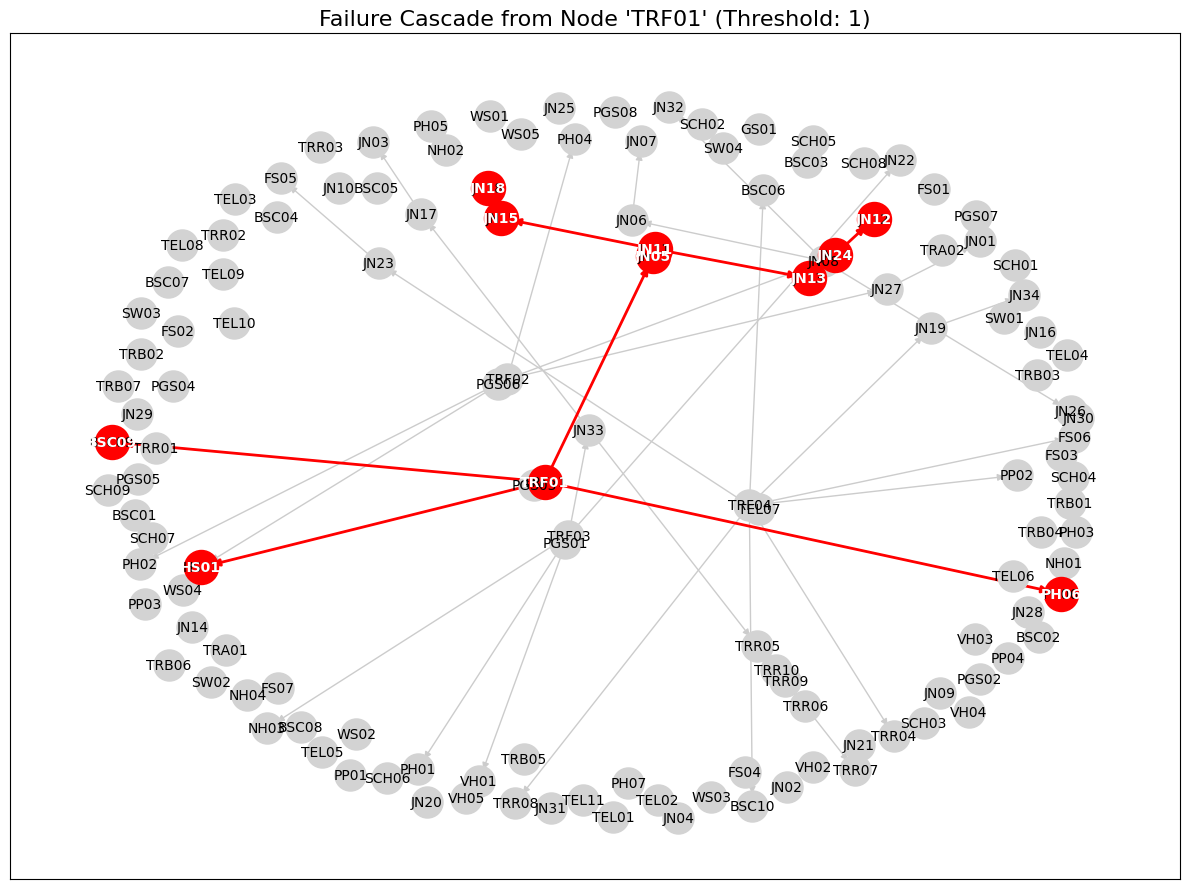

(['JN15',
  'JN05',
  'BSC09',
  'JN12',
  'JN18',
  'HS01',
  'JN24',
  'PH06',
  'JN13',
  'JN11'],
 (<Figure size 1200x900 with 1 Axes>,
  <Axes: title={'center': "Failure Cascade from Node 'TRF01' (Threshold: 1)"}>))

In [145]:
simulate_failure_with_plot(G=G, failed_node='TRF01', threshold=1)

In [78]:
failed_nodes = simulate_failure(G=G, failed_node='TRF02')

Failing: TRF02
Propagated failure to: JN07 (via dependency 3.0)
Propagated failure to: JN26 (via dependency 3.0)
Propagated failure to: HS01 (via dependency 3.0)
Propagated failure to: JN01 (via dependency 3.0)
Propagated failure to: JN27 (via dependency 3.0)
Propagated failure to: JN30 (via dependency 3.0)
Propagated failure to: PH04 (via dependency 3.0)
Propagated failure to: JN32 (via dependency 3.0)
Propagated failure to: JN08 (via dependency 3.0)
Propagated failure to: PH02 (via dependency 3.0)
Propagated failure to: JN06 (via dependency 3.0)


In [116]:
failed_nodes

['JN18',
 'JN12',
 'BSC09',
 'HS01',
 'JN15',
 'PH06',
 'JN13',
 'JN24',
 'JN05',
 'JN11']

In [82]:
check_node_and_edges(G, 'TRF02')


--- Analysis for Node: TRF02 ---

[Asset Attributes]
  - Asset_ID: TRF02
  - Asset_Type: Transport-Ferry
  - Asset_Name: FerryPort
  - lat: 50.763106
  - long: -1.2960338
  - criticality_score: 3
  - backup_asset_id: TRF01
  - status: failed
  - dependency_score: 3
  - exposure_score: 0
  - redundancy_score: 0
  - asset_score: 6

[Outgoing Dependencies (This asset depends on...)]
  -> TRF02 impacts PH04 with dependency_score (weight): 3.0
  -> TRF02 impacts JN27 with dependency_score (weight): 3.0
  -> TRF02 impacts JN08 with dependency_score (weight): 3.0
  -> TRF02 impacts HS01 with dependency_score (weight): 3.0
  -> TRF02 impacts PH02 with dependency_score (weight): 3.0

[Incoming Dependencies (...depend on this asset)]
  <- PGS06 is parent to TRF02 with dependency_score (weight): 3.0
------------------------------


##### Finished

In [109]:
attributes_to_remove = ['asset_resilience_score']
G = remove_node_attributes(G, attributes_to_remove)

Attempted to remove the following attributes from all nodes: asset_resilience_score


In [110]:
G.nodes['TRF02']

{'Asset_ID': 'TRF02',
 'Asset_Type': 'Transport-Ferry',
 'Asset_Name': 'FerryPort',
 'lat': 50.763106,
 'long': -1.2960338,
 'criticality_score': 3,
 'backup_asset_id': 'TRF01',
 'status': 'working',
 'dependency_score': 3,
 'exposure_score': 0,
 'redundancy_score': 0}

In [18]:
new_asset_file = '/home/akutekwea/VISTA-Development/scenario_data/01-additional-new-assets.csv'
new_asset_mapping_file = '/home/akutekwea/VISTA-Development/scenario_data/01-additional-new-assets-mapping.csv'

In [6]:
new_assets = pd.read_csv(new_asset_file)
new_dependencies = pd.read_csv(new_asset_mapping_file)

In [11]:
new_assets.head()

,Asset_ID,Asset_Type,Asset_Name,lat,long,criticality_score,backup_asset_id
0,PGS09,PowerGen/Substation,LowVoltageElectricitySubstationComplex,50.703494,-1.292065,3,NaN
1,LFS01,LiquidFuelStorage,LiquidFuelStorageComplex,50.748784,-1.288094,2,LFS02
2,LFS02,LiquidFuelStorage,LiquidFuelStorageComplex,50.745210,-1.287311,2,LFS03
3,LFS03,LiquidFuelStorage,LiquidFuelStorageComplex,50.755962,-1.292791,2,LFS01
4,TEL08,Telecomms,TelecommunicationsExchange,50.730509,-1.164576,3,NaN


In [12]:
new_dependencies.head(10)

,from_asset,to_asset,connection,dependency_score
0,PGS09,LFS02,PGS09-->LFS02,3
1,PGS09,LFS01,PGS09-->LFS01,3
2,PGS09,LFS03,PGS09-->LFS03,3
3,PGS09,TEL08,PGS09-->TEL08,3


In [7]:
def add_new_assets_to_graph(G, assets_df):
    """
    Adds new assets from a DataFrame to an existing graph.

    Each row in the DataFrame is treated as a new asset. The 'Asset_ID'
    is used as the node ID, and all other columns in the row are added
    as attributes to that node.

    Args:
        G (nx.DiGraph): The existing NetworkX directed graph to add assets to.
        assets_df (pd.DataFrame): A DataFrame containing the new assets.
                                  Must include an 'Asset_ID' column.

    Returns:
        nx.DiGraph: The graph with the new assets added as nodes.
    """
    if 'Asset_ID' not in assets_df.columns:
        raise ValueError("assets_df must contain an 'Asset_ID' column.")

    for index, row in assets_df.iterrows():
        # Use the 'Asset_ID' as the node identifier
        node_id = row['Asset_ID']
        
        # Convert the entire row to a dictionary to use as attributes
        attributes = row.to_dict()
        
        # Add the node to the graph with all its attributes
        if not G.has_node(node_id):
            G.add_node(node_id, **attributes)
        else:
            # If the node already exists, update its attributes
            nx.set_node_attributes(G, {node_id: attributes})
    
    #print(f"Added {len(G.number_of_nodes)} new nodes to the graph.")
    return G

In [25]:
G =  add_new_assets_to_graph(G, new_assets)

In [26]:
G.number_of_nodes()

133

In [10]:
G.nodes['PGS09']

{'Asset_ID': 'PGS09',
 'Asset_Type': 'PowerGen/Substation',
 'Asset_Name': 'LowVoltageElectricitySubstationComplex',
 'lat': 50.703494,
 'long': -1.2920646,
 'criticality_score': 3,
 'backup_asset_id': nan}

In [27]:
G = add_new_dependency_to_graph(G, new_dependencies)

In [28]:
G.number_of_edges()

51